### Домашняя работа по дисциплине ***Современные методы анализы данных*** 
**Темы 1–3: библиотека NumPy, библиотека Pandas, визуализация данных**

Для выполнения домашнего задания использовались материалы по ссылке
https://www.kaggle.com/datasets/rish59/financial-statements-of-major-companies2009-2023  
Dataset представляет собой финансовую отчетность компаний (US) из различных секторов бизнеса за период с 2009 по 2023 годы.  
Цель - провести полный цикл первичного исследования данных: от загрузки и предобработки до анализа взаимосвязей переменных и визуализации результатов.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

In [2]:
df = pd.read_csv('Financial Statements.csv', sep = ',')
df.head()

,Year,Company,Category,Market Cap(in B USD),Revenue,Gross Profit,Net Income,Earning Per Share,EBITDA,Share Holder Equity,...,Current Ratio,Debt/Equity Ratio,ROE,ROA,ROI,Net Profit Margin,Free Cash Flow per Share,Return on Tangible Equity,Number of Employees,Inflation Rate(in US)
0,2022,AAPL,IT,2066.94,394328.0,170782.0,99803.0,6.11,130541.0,50672.0,...,0.8794,2.3695,196.9589,28.2924,66.6994,25.3096,1.3146,196.9589,164000,8.0028
1,2021,AAPL,IT,2913.28,365817.0,152836.0,94680.0,5.61,120233.0,63090.0,...,1.0746,1.9768,150.0713,26.9742,54.9839,25.8818,1.3261,150.0713,154000,4.6979
2,2020,AAPL,IT,2255.97,274515.0,104956.0,57411.0,3.28,77344.0,65339.0,...,1.3636,1.7208,87.8664,17.7256,35.0054,20.9136,1.0183,87.8664,147000,1.2336
3,2019,AAPL,IT,1304.76,260174.0,98392.0,55256.0,2.97,76477.0,90488.0,...,1.5401,1.1940,61.0645,16.3230,30.3113,21.2381,-0.0388,61.0645,137000,1.8122
4,2018,AAPL,IT,748.54,265595.0,101839.0,59531.0,2.98,81801.0,107147.0,...,1.1329,1.0685,55.5601,16.2775,29.6348,22.4142,0.7414,55.5601,132000,2.4426


### Этап предварительной обработки данных

Для первичного анализа данных в помощью метода info проверяем, насколько тип данных соответствует ожидаемым типам согласно заявленным в полях названиям.
Dataset содержит 161 строку, пропуск обнаружен только по полю "Market Cap(in B USD)" - 160 значений, вместо 161.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161 entries, 0 to 160
Data columns (total 23 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Year                                 161 non-null    int64  
 1   Company                              161 non-null    object 
 2   Category                             161 non-null    object 
 3   Market Cap(in B USD)                 160 non-null    float64
 4   Revenue                              161 non-null    float64
 5   Gross Profit                         161 non-null    float64
 6   Net Income                           161 non-null    float64
 7   Earning Per Share                    161 non-null    float64
 8   EBITDA                               161 non-null    float64
 9   Share Holder Equity                  161 non-null    float64
 10  Cash Flow from Operating             161 non-null    float64
 11  Cash Flow from Investing        

***Ренейминг столбцов***

Обнаружено, что у столбца ***Company*** есть лиший пробел слева, для удобства дальнейшей обработки данных удалим лишние пробелы в начале и в конце названий столбов, также переименуем столбцы со скобками в названиях.

In [4]:
df.columns = df.columns.str.strip()
df = df.rename(columns={'Market Cap(in B USD)': 'Market Cap, bUSD', 'Inflation Rate(in US)': 'Inflation Rate'})
df.head()
# проверка результата
print(df.columns.tolist())

['Year', 'Company', 'Category', 'Market Cap, bUSD', 'Revenue', 'Gross Profit', 'Net Income', 'Earning Per Share', 'EBITDA', 'Share Holder Equity', 'Cash Flow from Operating', 'Cash Flow from Investing', 'Cash Flow from Financial Activities', 'Current Ratio', 'Debt/Equity Ratio', 'ROE', 'ROA', 'ROI', 'Net Profit Margin', 'Free Cash Flow per Share', 'Return on Tangible Equity', 'Number of Employees', 'Inflation Rate']


***Проверка на наличие пропусков и дубликатов***

In [5]:
# проверка пропусков по полю Market Cap(in B USD)
df_missing_value = df[df['Market Cap, bUSD'].isnull()]
df_missing_value.head()

,Year,Company,Category,"Market Cap, bUSD",Revenue,Gross Profit,Net Income,Earning Per Share,EBITDA,Share Holder Equity,...,Current Ratio,Debt/Equity Ratio,ROE,ROA,ROI,Net Profit Margin,Free Cash Flow per Share,Return on Tangible Equity,Number of Employees,Inflation Rate
51,2014,PYPL,FinTech,NaN,8025.0,4218.0,419.0,0.34,1784.0,8248.0,...,1.3224,0.1325,5.08,1.9118,5.08,5.2212,0.103,8.5458,15800,1.6222


In [6]:
df_grp = df[df['Company'] == 'PYPL'].groupby('Year')['Market Cap, bUSD'].mean().reset_index()
df_grp.head()

,Year,"Market Cap, bUSD"
0,2014,NaN
1,2015,44.23
2,2016,47.63
3,2017,88.48
4,2018,99.09


In [7]:
# замена NaN на 0, чтобы в последующем при расчете агрегатов (таких как mean) и при построении графиков не было пропусков
df.loc[df['Company'] == 'PYPL', 'Market Cap, bUSD'] = df.loc[df['Company'] == 'PYPL', 'Market Cap, bUSD'].fillna(0)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161 entries, 0 to 160
Data columns (total 23 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Year                                 161 non-null    int64  
 1   Company                              161 non-null    object 
 2   Category                             161 non-null    object 
 3   Market Cap, bUSD                     161 non-null    float64
 4   Revenue                              161 non-null    float64
 5   Gross Profit                         161 non-null    float64
 6   Net Income                           161 non-null    float64
 7   Earning Per Share                    161 non-null    float64
 8   EBITDA                               161 non-null    float64
 9   Share Holder Equity                  161 non-null    float64
 10  Cash Flow from Operating             161 non-null    float64
 11  Cash Flow from Investing        

In [8]:
# проверка результата
df_grp = df[df['Company'] == 'PYPL'].groupby('Year')['Market Cap, bUSD'].mean().reset_index()
df_grp.head()

,Year,"Market Cap, bUSD"
0,2014,0.00
1,2015,44.23
2,2016,47.63
3,2017,88.48
4,2018,99.09


После преобразований видно, что средняя теперь считается как 0, а не Nan, а общее количество значений во всех колонках равно 161.

Для проверки на дубликаты методом группировки находим уникальные сочетания по компании / год / категория бизнеса.  
Повторы более 1 будет свидетельствовать о наличии дубликатов. В данном случае их нет - Empty DataFrame

In [9]:
grouped = df.groupby(['Company', 'Category', 'Year']).size().reset_index(name='Count')

duplicates_only = grouped[grouped['Count'] > 1]
print(duplicates_only)

Empty DataFrame
Columns: [Company, Category, Year, Count]
Index: []


Приводим все значения в столбце ***Category*** к одному регистру

In [10]:
df['Category'] = df['Category'].str.upper()
df_check_after_upper = df.groupby('Category')['Revenue'].sum().reset_index()
df_check_after_upper

,Category,Revenue
0,BANK,1342742.820
1,ELEC,977144.702
2,FINANCE,345587.000
3,FINTECH,148775.000
4,FOOD,338030.200
5,IT,6189902.000
6,LOGI,2635460.000
7,MANUFACTURING,236237.000


Для удобства добавим расшифровку кода компаний, соединив их со списком **Top US Stock Tickers** *(CSV lists of US-listed stocks from NASDAQ)*.   
https://github.com/Ate329/top-us-stock-tickers 

In [11]:
import pandas as pd

df_nasgaq = pd.read_csv("https://raw.githubusercontent.com/Ate329/top-us-stock-tickers/main/tickers/all.csv")[['symbol', 'name', 'industry']]
df_nasgaq.head()

,symbol,name,industry
0,NVDA,NVIDIA Corporation Common Stock,Technology
1,GOOGL,Alphabet Inc. Class A Common Stock,Technology
2,GOOG,Alphabet Inc. Class C Capital Stock,Technology
3,AAPL,Apple Inc. Common Stock,Technology
4,MSFT,Microsoft Corporation Common Stock,Technology


In [12]:
df_merged = pd.merge(df, df_nasgaq, left_on = 'Company', right_on = 'symbol', how = 'left').drop(columns=['symbol'])
df_merged.head()

,Year,Company,Category,"Market Cap, bUSD",Revenue,Gross Profit,Net Income,Earning Per Share,EBITDA,Share Holder Equity,...,ROE,ROA,ROI,Net Profit Margin,Free Cash Flow per Share,Return on Tangible Equity,Number of Employees,Inflation Rate,name,industry
0,2022,AAPL,IT,2066.94,394328.0,170782.0,99803.0,6.11,130541.0,50672.0,...,196.9589,28.2924,66.6994,25.3096,1.3146,196.9589,164000,8.0028,Apple Inc. Common Stock,Technology
1,2021,AAPL,IT,2913.28,365817.0,152836.0,94680.0,5.61,120233.0,63090.0,...,150.0713,26.9742,54.9839,25.8818,1.3261,150.0713,154000,4.6979,Apple Inc. Common Stock,Technology
2,2020,AAPL,IT,2255.97,274515.0,104956.0,57411.0,3.28,77344.0,65339.0,...,87.8664,17.7256,35.0054,20.9136,1.0183,87.8664,147000,1.2336,Apple Inc. Common Stock,Technology
3,2019,AAPL,IT,1304.76,260174.0,98392.0,55256.0,2.97,76477.0,90488.0,...,61.0645,16.3230,30.3113,21.2381,-0.0388,61.0645,137000,1.8122,Apple Inc. Common Stock,Technology
4,2018,AAPL,IT,748.54,265595.0,101839.0,59531.0,2.98,81801.0,107147.0,...,55.5601,16.2775,29.6348,22.4142,0.7414,55.5601,132000,2.4426,Apple Inc. Common Stock,Technology


In [13]:
# проверяем качество соединения, видим, что не по всем строкам данные нашлись - 137 вместо 161.
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161 entries, 0 to 160
Data columns (total 25 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Year                                 161 non-null    int64  
 1   Company                              161 non-null    object 
 2   Category                             161 non-null    object 
 3   Market Cap, bUSD                     161 non-null    float64
 4   Revenue                              161 non-null    float64
 5   Gross Profit                         161 non-null    float64
 6   Net Income                           161 non-null    float64
 7   Earning Per Share                    161 non-null    float64
 8   EBITDA                               161 non-null    float64
 9   Share Holder Equity                  161 non-null    float64
 10  Cash Flow from Operating             161 non-null    float64
 11  Cash Flow from Investing        

Методом группировки выявляем те категории бизнесов, по которым обнаружились пропуски и заменяем значения на необходимые.

In [14]:
df_merged_miss = df_merged[df_merged['industry'].isna()].groupby(['Category'])['Revenue'].sum().reset_index()
df_merged_miss

,Category,Revenue
0,BANK,515288.82
1,FINANCE,345587.00


In [15]:
# замена NaN значений на заданные согласно категории бизнеса
df_merged.loc[(df_merged['Category'] == 'BANK') | (df_merged['Category'] == 'FINANCE'), 'industry'] = \
    df_merged.loc[(df_merged['Category'] == 'BANK') | (df_merged['Category'] == 'FINANCE'), 'industry'].fillna('Finance') 

# по компании подставляем значения из столбца Company (чтобы не оставлять NaN)
df_merged['name'] = df_merged['name'].fillna(df_merged['Company'])
df_merged.info()

# проверка корректности замены - должно быть 0
print(df_merged['industry'].isna().sum()) 
print(df_merged['name'].isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161 entries, 0 to 160
Data columns (total 25 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Year                                 161 non-null    int64  
 1   Company                              161 non-null    object 
 2   Category                             161 non-null    object 
 3   Market Cap, bUSD                     161 non-null    float64
 4   Revenue                              161 non-null    float64
 5   Gross Profit                         161 non-null    float64
 6   Net Income                           161 non-null    float64
 7   Earning Per Share                    161 non-null    float64
 8   EBITDA                               161 non-null    float64
 9   Share Holder Equity                  161 non-null    float64
 10  Cash Flow from Operating             161 non-null    float64
 11  Cash Flow from Investing        

Методом группировки проверяем корректность преобразований, ***Revenue*** равен данным до merge в разрезе ***Category***, к ним добавлены значения ***industry*** без пропусков.

In [16]:
df_merged_grp = df_merged.groupby(['Category', 'industry'])['Revenue'].sum().reset_index()
df_merged_grp

,Category,industry,Revenue
0,BANK,Finance,1342742.820
1,ELEC,Technology,977144.702
2,FINANCE,Finance,345587.000
3,FINTECH,Industrials,148775.000
4,FOOD,Consumer Discretionary,338030.200
5,IT,Technology,6189902.000
6,LOGI,Consumer Discretionary,2635460.000
7,MANUFACTURING,Utilities,236237.000


### Этап описания переменных

- `Year` — отчетный год (**дата**)
- `Company` — наименование компании (**категориальная**)
- `Category` — сектор бизнеса (**категориальная**)
- `Market Cap, bUSD` — рыночная капитализация компании, в млрд. долларов (**числовая**)
- `Revenue` — выручка (**числовая**)
- `Gross Profit` — валовая прибыль (**числовая**)
- `Net Income` — чистая прибыль (**числовая**)
- `Earning Per Share` — Прибыль на акцию (EPS) (**числовая**)
- `EBITDA` — EBITDA (прибыль до вычета процентов, налогов, износа и амортизации) (**числовая**)
- `Share Holder Equity` — акционерный капитал (**числовая**)
- `Cash Flow from Operating` — 	денежный поток от операционной деятельности (**числовая**)
- `Cash Flow from Investing` — денежный поток от инвестиционной деятельности (**числовая**)
- `Cash Flow from Financial Activities` — денежный поток от финансовой деятельности (**числовая**)
- `Current Ratio` — коэффициент текущей ликвидности (**числовая**)
- `Debt/Equity Ratio` — коэффициент соотношения заёмного и собственного капитала (D/E) (**числовая**)
- `ROE` — рентабельность собственного капитала (**числовая**)
- `ROA` — рентабельность активов (**числовая**)
- `ROI` — рентабельность инвестиций (**числовая**)
- `Net Profit Margin` — рентабельность чистой прибыли (чистая маржа) (**числовая**)
- `Free Cash Flow per Share` — свободный денежный поток на акцию (**числовая**)
- `Return on Tangible Equity` — рентабельность материального собственного капитала (**числовая**)
- `Number of Employees` — количество сотрудников (**числовая**)
- `Inflation Rate` — уровень инфляции (**числовая**)
- `name` — полное наименование компании (**категориальная**)
- `industry` — наименование индустрии (**категориальная**)

Ординальной переменной нет в исходных данных, поэтому добавим их в DataFrame вручную - назовем ***Size_Rank***.
Исходим из следующего порядка ранжирования:  
`Micro-Cap` - *менее 250 mUSD*  
`Small-Cap` - *250 mUSD – 2 bUSD*  
`Mid-Cap` - *2 bUSD – 10 bUSD*  
`Large-Cap` - *10 bUSD – 200 bUSD*  
`Mega-Cap`- *более 200 bUSD* 

In [17]:
# для наглядности группируем компании по индустриям и среднему значению рыночной капитализации,
# чтобы сформировать ожидания по количеству компаний и их возможным размерам
df_merged_grp_by_company = df_merged.groupby(['Company', 'industry'])['Market Cap, bUSD'].mean().reset_index()
df_merged_grp_by_company

,Company,industry,"Market Cap, bUSD"
0,AAPL,Technology,991.332857
1,AIG,Finance,47.514286
2,AMZN,Consumer Discretionary,551.926429
3,BCS,Finance,43.922857
4,GOOG,Technology,657.051429
5,INTC,Technology,157.731429
6,MCD,Consumer Discretionary,130.867857
7,MSFT,Technology,910.826667
8,NVDA,Technology,192.824000
9,PCG,Utilities,22.591429


In [18]:
# формируем ординальную переменную

bins = bins = [0, 0.25, 2, 10, 200, np.inf]
labels = ['Micro-Cap', 'Small-Cap', 'Mid-Cap', 'Large-Cap', 'Mega-Cap']
categorical = pd.cut(df_merged['Market Cap, bUSD'], bins=bins, labels=labels, right=False)

# добавляем в DataFrame дополнительную колонку со значением ординальной переменной в зависимости от рыночной капитализации
df_merged['Size_Rank'] = categorical

df_merged.head()

,Year,Company,Category,"Market Cap, bUSD",Revenue,Gross Profit,Net Income,Earning Per Share,EBITDA,Share Holder Equity,...,ROA,ROI,Net Profit Margin,Free Cash Flow per Share,Return on Tangible Equity,Number of Employees,Inflation Rate,name,industry,Size_Rank
0,2022,AAPL,IT,2066.94,394328.0,170782.0,99803.0,6.11,130541.0,50672.0,...,28.2924,66.6994,25.3096,1.3146,196.9589,164000,8.0028,Apple Inc. Common Stock,Technology,Mega-Cap
1,2021,AAPL,IT,2913.28,365817.0,152836.0,94680.0,5.61,120233.0,63090.0,...,26.9742,54.9839,25.8818,1.3261,150.0713,154000,4.6979,Apple Inc. Common Stock,Technology,Mega-Cap
2,2020,AAPL,IT,2255.97,274515.0,104956.0,57411.0,3.28,77344.0,65339.0,...,17.7256,35.0054,20.9136,1.0183,87.8664,147000,1.2336,Apple Inc. Common Stock,Technology,Mega-Cap
3,2019,AAPL,IT,1304.76,260174.0,98392.0,55256.0,2.97,76477.0,90488.0,...,16.3230,30.3113,21.2381,-0.0388,61.0645,137000,1.8122,Apple Inc. Common Stock,Technology,Mega-Cap
4,2018,AAPL,IT,748.54,265595.0,101839.0,59531.0,2.98,81801.0,107147.0,...,16.2775,29.6348,22.4142,0.7414,55.5601,132000,2.4426,Apple Inc. Common Stock,Technology,Mega-Cap


In [19]:
# проверяем, что новый столбец добавился корректно, по-прежнему 161 строки, вид Size_Rank присвоился корректно

df_merged_grp_by_size = df_merged.groupby(['Company', 'Year', 'Size_Rank'], observed=True)['Market Cap, bUSD'].mean().reset_index()
df_merged_grp_by_size

,Company,Year,Size_Rank,"Market Cap, bUSD"
0,AAPL,2009,Large-Cap,189.80
1,AAPL,2010,Mega-Cap,296.89
2,AAPL,2011,Mega-Cap,376.40
3,AAPL,2012,Mega-Cap,500.61
4,AAPL,2013,Mega-Cap,504.79
...,...,...,...,...
156,SHLDQ,2014,Mid-Cap,3.51
157,SHLDQ,2015,Mid-Cap,2.19
158,SHLDQ,2016,Small-Cap,1.11
159,SHLDQ,2017,Small-Cap,0.37


Таким образом у нас достаточно переменных, чтобы рассмотреть следующие типы связей и исследовательские вопросы:  

***1. Верно ли утверждение, что с ростом числа сотрудников компании растет ее выручка?***  
    - числовая (Number of Employees) & числовая (Revenue)  
    
***2. Какие категории компаний требуют большего числа сотрудников?***  
    - числовая (Number of Employees) & категориальная (Category)  

***3. Влияет ли динамика инфляции на капитализацию компаний?***  
    - числовая (Inflation Rate) & ординальная (Size_Rank)  
    
***4. Зависит ли размер капитализации компании от ее категории?***  
    - категориальная (Category) & ординальная (Size_Rank)    
    
***5. Какие факторы влияют на EBITDA компании?***  
    - EBITDA (числовой) & остальные числовые переменные

**Вопрос 1. Анализ, метрики, графики**

In [20]:
numeric_vars = ['Number of Employees', 'Revenue']
df_merged[numeric_vars].head()
df_merged[numeric_vars].describe().round(2) 

,Number of Employees,Revenue
count,161.00,161.00
mean,145718.77,75862.60
std,223438.90,90786.90
min,5420.00,3326.44
25%,29900.00,22820.40
50%,96000.00,45992.04
75%,147000.00,77849.00
max,1608000.00,513983.00


Если обратить внимание на разброс между **75%** и **max**, то можно предположить, что есть большие выбросы в данных, поэтому использовать коэффициент Пирсона будет не совсем корректно. Возможно, стоит посчитать коэффициент Пирсона на логарифмах, чтобы смягчить влияние выборосов, или сравнить с коэффициентом Спирмена.

In [21]:
from scipy.stats import spearmanr, pearsonr

spearman_corr = spearmanr(df_merged['Number of Employees'], df_merged['Revenue'])
pearson_corr = pearsonr(df_merged['Number of Employees'], df_merged['Revenue'])
log_pearson = pearsonr(np.log(df_merged['Number of Employees']), np.log(df_merged['Revenue']))[0]

print(f"Спирмен: {spearman_corr:}")
print(f"Пирсон: {pearson_corr:}")
print(f"Пирсон_логарифмы: {log_pearson:}")

Спирмен: SignificanceResult(statistic=np.float64(0.5682584459959512), pvalue=np.float64(3.771602159163613e-15))
Пирсон: PearsonRResult(statistic=np.float64(0.6346571342463412), pvalue=np.float64(1.5711863190173835e-19))
Пирсон_логарифмы: 0.6919594484349387


Судя по коэффициенту Пирсона равному **0.692** можно сделать вывод о том, что при увеличении числа сотрудников на 1% выручка растет в среднем на 0.692%. Ниже представлены графики (линейный и логарифмический).

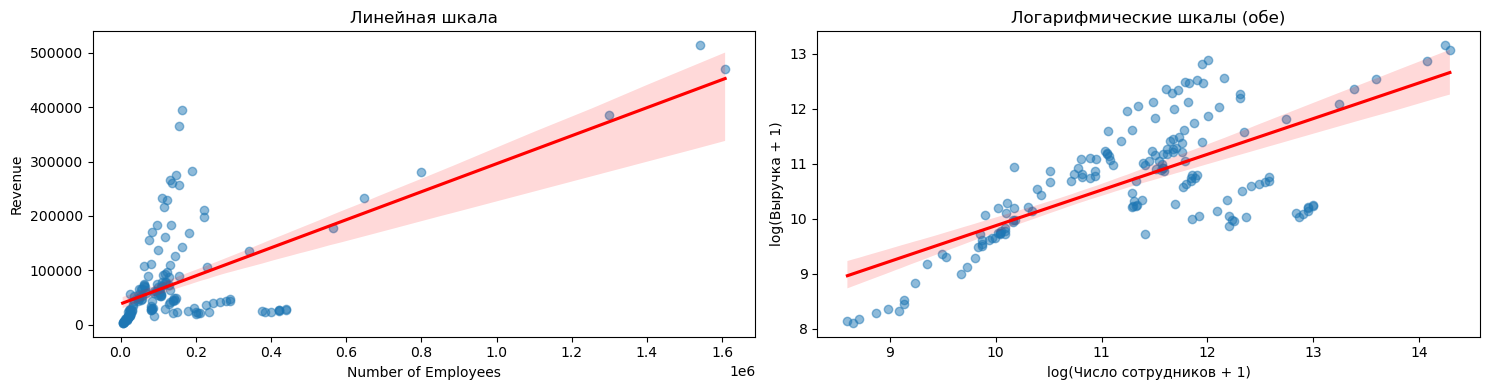

***Утверждение ВЕРНО: между ростом числа сотрудников и выручки есть связь***


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# вариант линейный
sns.regplot(data=df_merged, x='Number of Employees', y='Revenue', scatter_kws={'alpha':0.5}, line_kws={'color':'red'}, ax=axes[0])
axes[0].set_title('Линейная шкала')

# вариант с логарифмами
df_log = df_merged.copy() # копия DataFrame
df_log['log_employees'] = np.log1p(df_merged['Number of Employees'])  
df_log['log_revenue'] = np.log1p(df_merged['Revenue'])

sns.regplot(data=df_log, x='log_employees', y='log_revenue', scatter_kws={'alpha':0.5}, line_kws={'color':'red'}, ax=axes[1])
axes[1].set_title('Логарифмические шкалы (обе)')
axes[1].set_xlabel('log(Число сотрудников + 1)')
axes[1].set_ylabel('log(Выручка + 1)')

plt.tight_layout()
plt.show()

# Вывод ответав зависимости от значения коэффициента
if log_pearson > 0.5:
    print("***Утверждение ВЕРНО: между ростом числа сотрудников и выручки есть связь***")
elif log_pearson > 0.2:
    print("***Слабая положительная связь: утверждение скорее верно, но есть исключения***")
else:
    print("***Утверждение НЕВЕРНО: четкой связи нет***")

**Вывод:** с экономической точки зрения, нельзя сказать, что рост числа сотрудников первичнее роста выручки. В разных случаях различные факторы могут быть триггером роста. Например, бизнес сам по себе может стать прибыльным с высокими показателями выручки (за счет инноваций, предложения уникальных продуктов, услуг, а может и за счет макроэкономической ситуации), руководство может принять решение о расширении географии бизнеса, что влечет за собой увеличение штата сотрудников. В данном примере рост выручки (а лучше прибыли) первичнее. С другой стороны, крупные компании уже с высокими показателями выручки часто доходят до стадии, когда большой штат сотрудников "раздувается", теряется эффективность процессов, часто появляется большая "прослойка" линейных менеджеров, и в конечно итоге, компании вынуждены сокращать штат до разумных размеров. Это может свидетельствовать о том, что связь между ростом числа сотрудников с ростом выручки может иметь предел, и в какой-то момент она становится неэффективной. Но для подтверждения этой гипотезы необходимы отдельные исследования.

**Вопрос 2. Анализ, метрики, графики**

In [23]:
df_merged_grp_by_category = df_merged.groupby(['Category', 'Size_Rank'], observed=True)['Number of Employees'].mean().round(0).reset_index()
df_merged_grp_by_category

,Category,Size_Rank,Number of Employees
0,BANK,Mid-Cap,79500.0
1,BANK,Large-Cap,85146.0
2,ELEC,Mid-Cap,6710.0
3,ELEC,Large-Cap,65017.0
4,ELEC,Mega-Cap,65427.0
5,FINANCE,Micro-Cap,89900.0
6,FINANCE,Small-Cap,159000.0
7,FINANCE,Mid-Cap,256143.0
8,FINTECH,Micro-Cap,15800.0
9,FINTECH,Large-Cap,21417.0


In [24]:
# cтатистика по категориям, для чистоты анализа отберем одну категорию, в которой представлены несколько видов бизнеса - Mega-Cap 
stats = df_merged[df_merged['Size_Rank'] == 'Mega-Cap'].groupby('Category')['Number of Employees'].agg(['mean', 'median', 'std'])
print(stats.sort_values('mean', ascending=False))

                mean    median            std
Category                                     
LOGI      878837.500  722750.0  536196.264540
FOOD      200000.000  200000.0            NaN
IT        115714.150  118000.0   45385.085668
ELEC       65427.375   64448.0   48578.414077
FINTECH    28700.000   28700.0    3111.269837


Если сравнить среднюю с медианой по каждой категории, можно сделать следующие выводы по категориям, которые подтверждаются деталями ниже:
- LOGI (представлена одной компанией), средняя выше медианы за счет стремительного роста компании в 2020 году
- FOOD (представлена одной компанией), средняя равна медиане т.к. данные только за один год
- IT (представлена несколькими компаниями), наиболее показательная группа -> отсутствие сильных выбросов в данных

In [25]:
df_merged_grp_by_LOGI = df_merged[ (df_merged['Category'] == 'LOGI') & (df_merged['Size_Rank'] == 'Mega-Cap')].groupby(['Size_Rank', 'Company', 'Year'], observed=True)['Number of Employees'].sum().round(0).reset_index()
df_merged_grp_by_LOGI

,Size_Rank,Company,Year,Number of Employees
0,Mega-Cap,AMZN,2015,230800
1,Mega-Cap,AMZN,2016,341400
2,Mega-Cap,AMZN,2017,566000
3,Mega-Cap,AMZN,2018,647500
4,Mega-Cap,AMZN,2019,798000
5,Mega-Cap,AMZN,2020,1298000
6,Mega-Cap,AMZN,2021,1608000
7,Mega-Cap,AMZN,2022,1541000


In [26]:
df_merged_grp_by_FOOD = df_merged[ (df_merged['Category'] == 'FOOD') & (df_merged['Size_Rank'] == 'Mega-Cap')].groupby(['Size_Rank', 'Company', 'Year'], observed=True)['Number of Employees'].sum().round(0).reset_index()
df_merged_grp_by_FOOD

,Size_Rank,Company,Year,Number of Employees
0,Mega-Cap,MCD,2020,200000


In [27]:
df_merged_grp_by_IT = df_merged[ (df_merged['Category'] == 'IT') & (df_merged['Size_Rank'] == 'Mega-Cap')].groupby(['Size_Rank', 'Company'], observed=True)['Number of Employees'].mean().round(0).reset_index()
df_merged_grp_by_IT

,Size_Rank,Company,Number of Employees
0,Mega-Cap,AAPL,111785.0
1,Mega-Cap,GOOG,91780.0
2,Mega-Cap,MSFT,138267.0


Это подтверждается и визуализацией boxplot - большие выбросы по LOGI.

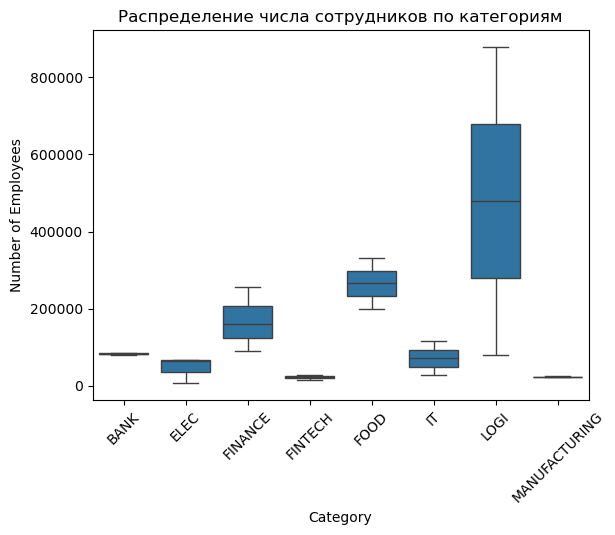

In [28]:
sns.boxplot(data=df_merged_grp_by_category, x='Category', y='Number of Employees')
plt.xticks(rotation=45)
plt.title('Распределение числа сотрудников по категориям')
plt.show()

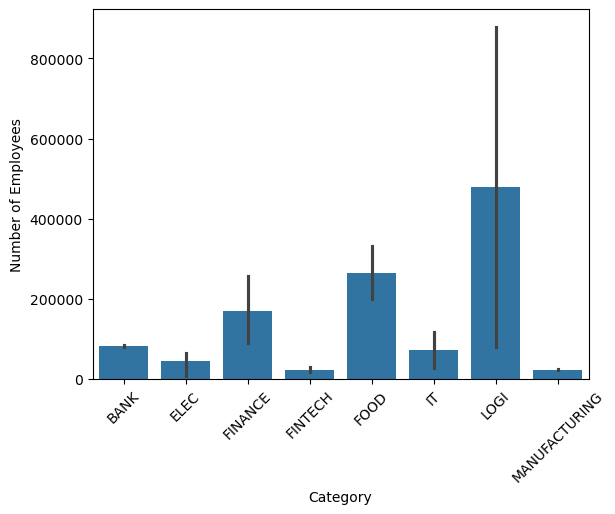

In [29]:
# cреднее значение
sns.barplot(data=df_merged_grp_by_category, x='Category', y='Number of Employees', 
            estimator='mean', errorbar='ci')
plt.xticks(rotation=45)
plt.show()

**Вывод**: категория ***LOGI*** требует большего числа сотрудников (при прочих равных услвиях, когда рассматриваемые компании относятся к одной категории по размерам капитализации Mega-Cap, допускаем, что компании, достигшие этого уровня скорее всего имеют схожую расширенную географию функционирования), следующая по очередности ***FOOD***, за ним ***IT***.

**Вопрос 3. Анализ, метрики, графики**

Отфильтруем данные для анализа и сгруппируем по компании, размеру и году.

In [30]:
df_merged_grp_infl = df_merged.groupby(['Company', 'Size_Rank', 'Year'], observed=True)['Inflation Rate'].mean().round(0).reset_index()
df_merged_grp_infl

,Company,Size_Rank,Year,Inflation Rate
0,AAPL,Large-Cap,2009,-0.0
1,AAPL,Mega-Cap,2010,2.0
2,AAPL,Mega-Cap,2011,3.0
3,AAPL,Mega-Cap,2012,2.0
4,AAPL,Mega-Cap,2013,1.0
...,...,...,...,...
156,SHLDQ,Mid-Cap,2011,3.0
157,SHLDQ,Mid-Cap,2012,2.0
158,SHLDQ,Mid-Cap,2013,1.0
159,SHLDQ,Mid-Cap,2014,2.0


In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder

# создадим лаговую переменную для Size_Rank (предыдущий год)
df_merged_grp_infl = df_merged_grp_infl.sort_values(['Company', 'Year'])

# определяем изменение Size_Rank
df_merged_grp_infl['Size_Rank_Change'] = df_merged_grp_infl.groupby('Company')['Size_Rank'].transform(
    lambda x: x != x.shift(1)
).replace({True: 'Changed', False: 'Stable'})

rank_order = {'Small-Cap': 0, 'Mid-Cap': 1, 'Large-Cap': 2, 'Mega-Cap': 3}
df_merged_grp_infl['Size_Rank_Num'] = df_merged_grp_infl['Size_Rank'].map(rank_order)
df_merged_grp_infl['Size_Rank_Increase'] = df_merged_grp_infl.groupby('Company')['Size_Rank_Num'].diff() > 0
df_merged_grp_infl['Size_Rank_Increase'] = df_merged_grp_infl['Size_Rank_Increase'].fillna(False)

# логистическая регрессия
from scipy.stats import chi2_contingency

# анализ: влияет ли инфляция на повышение ранга?
X = df_merged_grp_infl[['Inflation Rate']].dropna()
y = df_merged_grp_infl.loc[X.index, 'Size_Rank_Increase']

model = LogisticRegression()
model.fit(X, y)

print(f"Коэффициент для инфляции: {model.coef_[0][0]}")

Коэффициент для инфляции: -0.061269551705054257


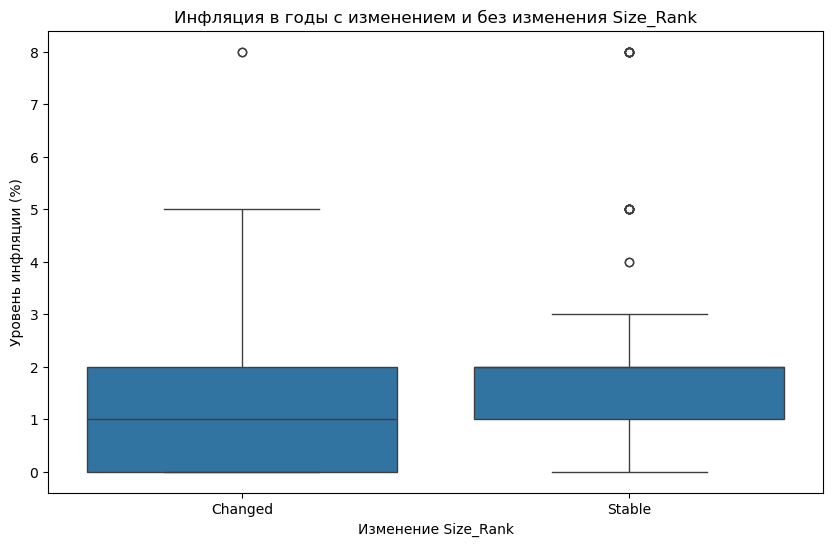

                  count      mean       std  min  25%  50%  75%  max
Size_Rank_Change                                                    
Changed            32.0  1.656250  2.164365 -0.0 -0.0  1.0  2.0  8.0
Stable            129.0  2.348837  1.926992  0.0  1.0  2.0  2.0  8.0


In [32]:
# отделяем компании, которые изменили Size_Rank
changed_companies = df_merged_grp_infl[df_merged_grp_infl['Size_Rank_Change'] == 'Changed']

# сравним инфляцию в год изменения vs предыдущий год
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_merged_grp_infl, x='Size_Rank_Change', y='Inflation Rate')
plt.title('Инфляция в годы с изменением и без изменения Size_Rank')
plt.ylabel('Уровень инфляции (%)')
plt.xlabel('Изменение Size_Rank')
plt.show()
print(df_merged_grp_infl.groupby('Size_Rank_Change')['Inflation Rate'].describe())

**Вывод:** анализ показал, что годы с изменением Size_Rank характеризуются более низкой инфляцией по сравнению со стабильными годами.
Медианная инфляция в годы изменений составляет 1.0% против 2.0% в стабильные годы. 
Средняя инфляция также ниже в группе изменений (1.66% против 2.35%).
Изменения Size_Rank происходят в периоды более мягкой денежно-кредитной политики или экономической стагнации с низкой инфляцией. Либо, наоборот, низкая инфляция создаёт условия для пересмотра рангов.

**Вопрос 4. Анализ, метрики, графики**

In [33]:
from scipy.stats import chi2_contingency, spearmanr

# создадим таблицу сопряженности
contingency_table = pd.crosstab(df_merged_grp_by_category['Category'], df_merged_grp_by_category['Size_Rank'], normalize='index')
print("Распределение Size_Rank по категориям (в %):")
print(contingency_table.round(4) * 100)

Распределение Size_Rank по категориям (в %):
Size_Rank      Micro-Cap  Small-Cap  Mid-Cap  Large-Cap  Mega-Cap
Category                                                         
BANK                0.00       0.00    50.00      50.00      0.00
ELEC                0.00       0.00    33.33      33.33     33.33
FINANCE            33.33      33.33    33.33       0.00      0.00
FINTECH            33.33       0.00     0.00      33.33     33.33
FOOD                0.00       0.00     0.00      50.00     50.00
IT                  0.00       0.00     0.00      50.00     50.00
LOGI                0.00       0.00     0.00      50.00     50.00
MANUFACTURING       0.00       0.00    50.00      50.00      0.00


<Figure size 1200x600 with 0 Axes>

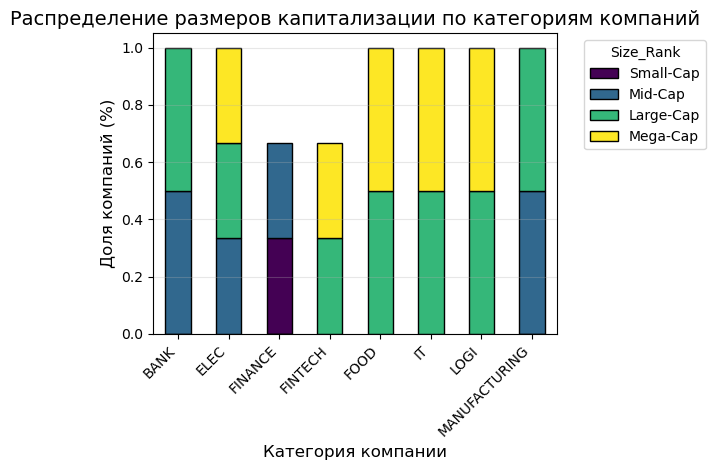

In [34]:
rank_order = ['Small-Cap', 'Mid-Cap', 'Large-Cap', 'Mega-Cap']
contingency_table = contingency_table[rank_order]

plt.figure(figsize=(12, 6))
contingency_table.plot(kind='bar', stacked=True, colormap='viridis', edgecolor='black')
plt.title('Распределение размеров капитализации по категориям компаний', fontsize=14)
plt.xlabel('Категория компании', fontsize=12)
plt.ylabel('Доля компаний (%)', fontsize=12)
plt.legend(title='Size_Rank', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [35]:
# проверим независимость категорий
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Статистика Хи-квадрат: {chi2:.4f}")
print(f"P-value: {p_value:.6f}")

if p_value < 0.05:
    print("Есть статистически значимая связь между Category и Size_Rank")
else:
    print("Нет статистически значимой связи")

Статистика Хи-квадрат: 6.7722
P-value: 0.998548
Нет статистически значимой связи


**Вывод:** между Category и Size_Rank нет статистически значимой связи.

**Вопрос 5. Анализ, метрики, графики**

Скопируем DataFrame и подготовим данные для анализа - отбросим лишние колонки.

In [36]:
df_merged_copy = df_merged.drop(columns=['Year', 'Category', 'Size_Rank', 'name', 'industry', 'Cash Flow from Operating', 'Cash Flow from Investing', 'Cash Flow from Financial Activities', 'Market Cap, bUSD', 'Inflation Rate', 'Return on Tangible Equity', 'Free Cash Flow per Share', 'Earning Per Share', 'Debt/Equity Ratio' ,'Current Ratio'])

df_merged_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161 entries, 0 to 160
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Company              161 non-null    object 
 1   Revenue              161 non-null    float64
 2   Gross Profit         161 non-null    float64
 3   Net Income           161 non-null    float64
 4   EBITDA               161 non-null    float64
 5   Share Holder Equity  161 non-null    float64
 6   ROE                  161 non-null    float64
 7   ROA                  161 non-null    float64
 8   ROI                  161 non-null    float64
 9   Net Profit Margin    161 non-null    float64
 10  Number of Employees  161 non-null    int64  
dtypes: float64(9), int64(1), object(1)
memory usage: 14.0+ KB


In [37]:
#соберем числовые переменные в DataFrame
numerics = df_merged_copy.columns[1:]
df_merged_copy[numerics].describe().round(2)

,Revenue,Gross Profit,Net Income,EBITDA,Share Holder Equity,ROE,ROA,ROI,Net Profit Margin,Number of Employees
count,161.00,161.00,161.00,161.00,161.00,161.00,161.00,161.00,161.00,161.00
mean,75862.60,37383.46,12276.61,20174.02,57178.01,12.43,7.78,11.88,13.68,145718.77
std,90786.90,41669.09,19417.42,26342.03,54098.21,44.78,8.80,93.38,13.40,223438.90
min,3326.44,1174.27,-12244.00,-6860.00,-8210.30,-212.61,-23.72,-742.11,-44.70,5420.00
25%,22820.40,10396.00,844.00,2310.00,12353.00,5.08,0.83,2.76,4.83,29900.00
50%,45992.04,19561.00,4757.80,9958.00,47791.00,14.50,6.64,13.47,15.30,96000.00
75%,77849.00,47722.00,14136.00,27765.00,91570.70,28.19,14.70,20.47,22.93,147000.00
max,513983.00,225152.00,99803.00,130541.00,256144.00,196.96,31.15,884.86,36.69,1608000.00


In [38]:
# воспользуемся функцией из материалов занятий
def show_distribution(df_merged_copy, variables):
    ncols = len(variables)

    fig_length = 5 * ncols

    fig, axes = plt.subplots(2, ncols, figsize=(fig_length, fig_length // 2.5))

    for index, variable in enumerate(variables):
        data_variable = df_merged_copy[variable].dropna(ignore_index=True)

        variable_mean = data_variable.mean()
        variable_median = data_variable.median()

        ## histogram
        axes[0, index].hist(data_variable, edgecolor='black', bins=20, color='darkblue', alpha=.3)
        axes[0, index].set_title(variable)

        # add vertical lines for mean and median
        axes[0, index].axvline(variable_mean, color='red', label='mean')  # default linestyle is 'solid'
        axes[0, index].axvline(variable_median, color='orange', linestyle='dashed', label='median')  # for horizontal line use axhline
            # (coordinate Y)

        if index == 0:
            axes[0, index].set_ylabel('histogram')

        # add legend
        if index == ncols - 1:
            axes[0, index].legend()

        ## boxplot
        axes[1, index].boxplot(data_variable, vert=False)
        axes[1, index].set_yticks([])

        if index == 0:
            axes[1, index].set_ylabel('boxplot')

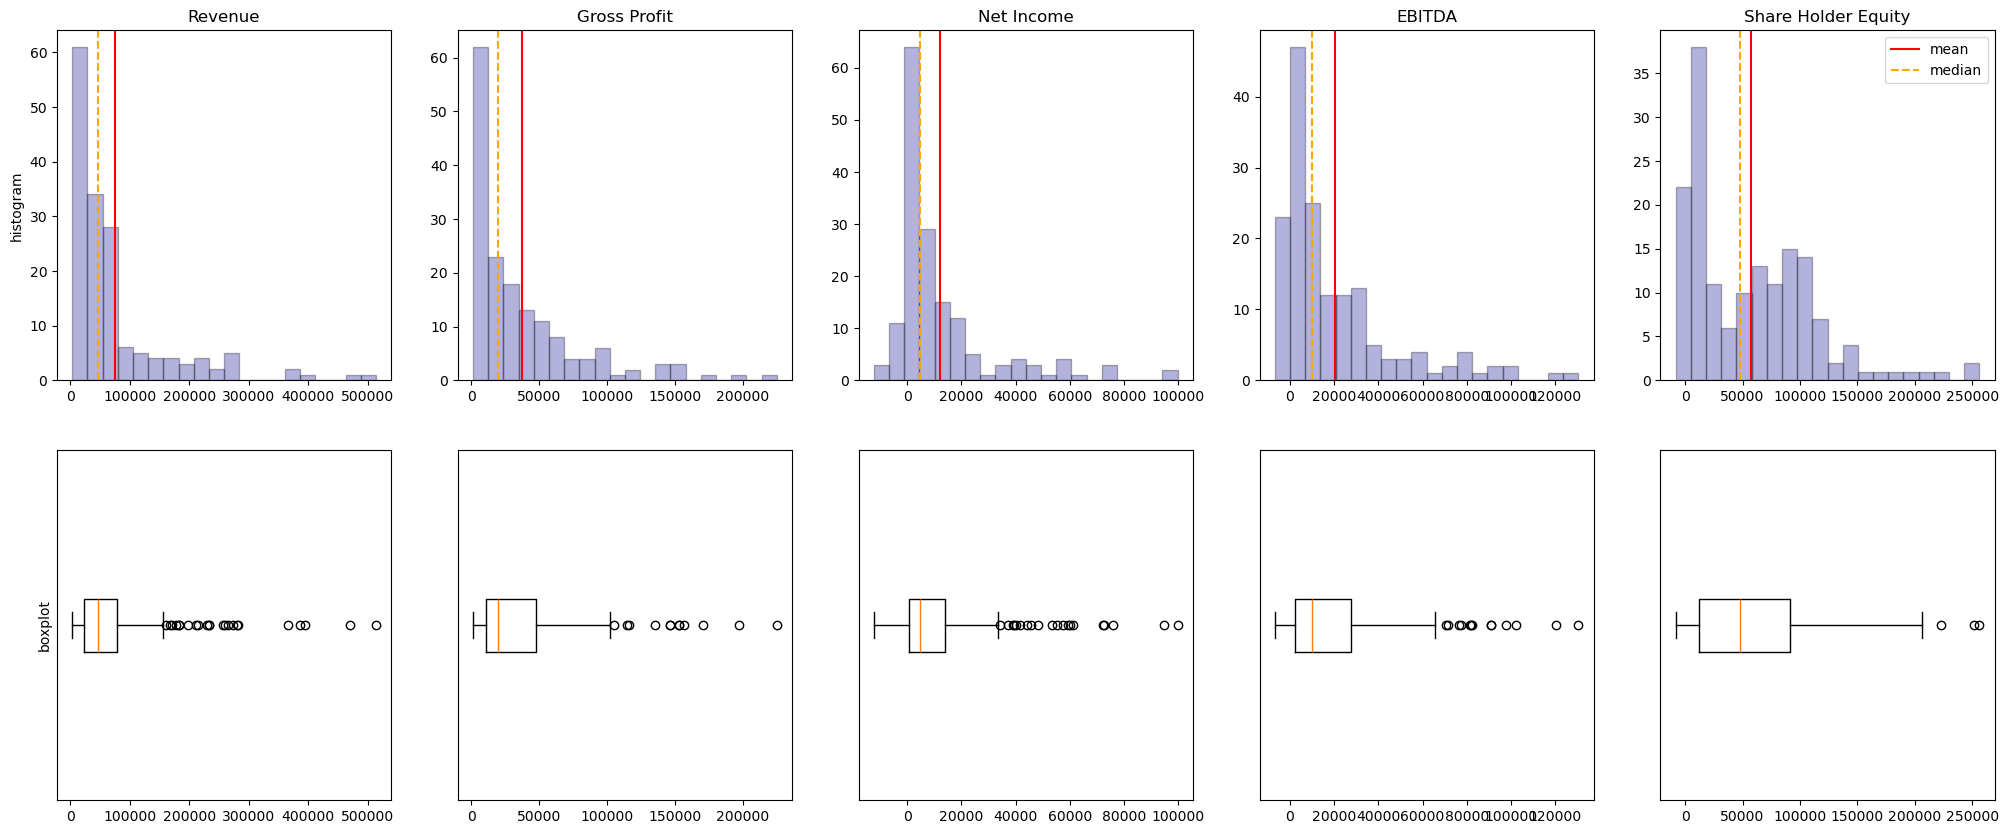

In [39]:
numerics = df_merged_copy.columns[1:]
show_distribution(df_merged_copy, numerics[:5])

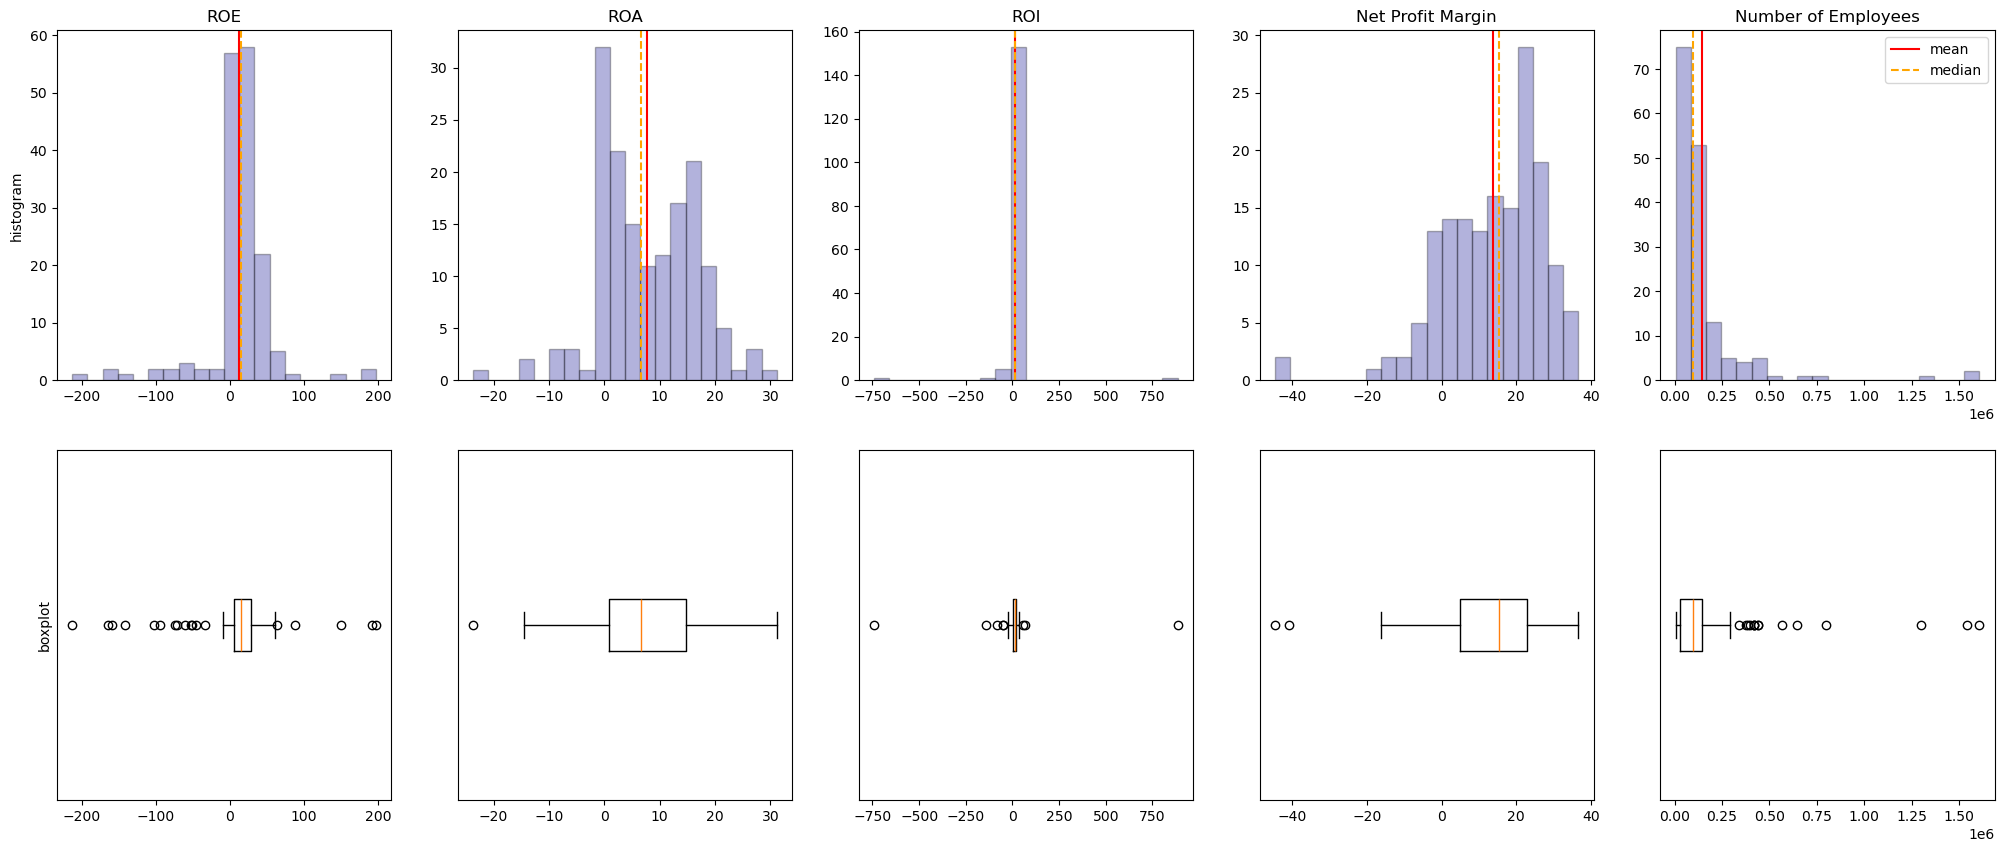

In [40]:
numerics = df_merged_copy.columns[1:]
show_distribution(df_merged_copy, numerics[5:])

In [41]:
corr_matrix = df_merged_copy.drop(columns=['Company']).corr().round(2)
corr_matrix

,Revenue,Gross Profit,Net Income,EBITDA,Share Holder Equity,ROE,ROA,ROI,Net Profit Margin,Number of Employees
Revenue,1.00,0.95,0.72,0.83,0.59,0.34,0.30,0.06,0.16,0.63
Gross Profit,0.95,1.00,0.78,0.86,0.71,0.34,0.36,0.07,0.27,0.56
Net Income,0.72,0.78,1.00,0.96,0.61,0.46,0.61,0.11,0.54,0.09
EBITDA,0.83,0.86,0.96,1.00,0.65,0.42,0.57,0.10,0.46,0.23
Share Holder Equity,0.59,0.71,0.61,0.65,1.00,0.22,0.24,0.03,0.28,0.14
ROE,0.34,0.34,0.46,0.42,0.22,1.00,0.24,0.08,0.25,-0.01
ROA,0.30,0.36,0.61,0.57,0.24,0.24,1.00,0.05,0.82,-0.01
ROI,0.06,0.07,0.11,0.10,0.03,0.08,0.05,1.00,0.13,-0.00
Net Profit Margin,0.16,0.27,0.54,0.46,0.28,0.25,0.82,0.13,1.00,-0.07
Number of Employees,0.63,0.56,0.09,0.23,0.14,-0.01,-0.01,-0.00,-0.07,1.00


Видим несколько переменных, которые имеют коэффициент корреляции с таргетом >= 0.5 по модулю: Revenue, Gross Profit, Net Income, Share Holder Equity и ROA. Построим соответствующие визуализации, например, с Revenue:

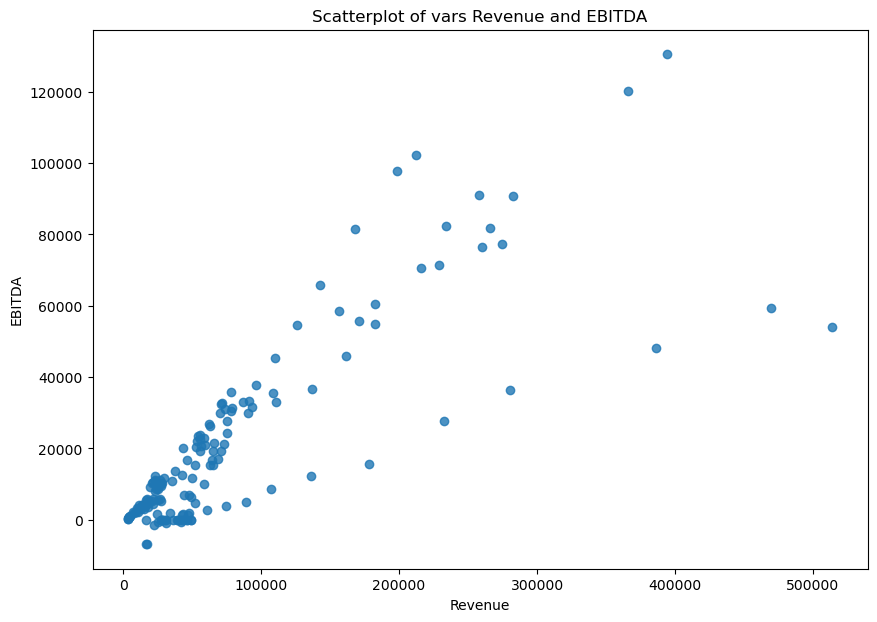

In [42]:
fig, ax = plt.subplots(figsize=(10, 7))

ax.plot(df_merged_copy['Revenue'].values, df_merged_copy['EBITDA'].values, 'o', alpha=.8)

ax.set_title('Scatterplot of vars Revenue and EBITDA')
ax.set_xlabel('Revenue')
ax.set_ylabel('EBITDA');

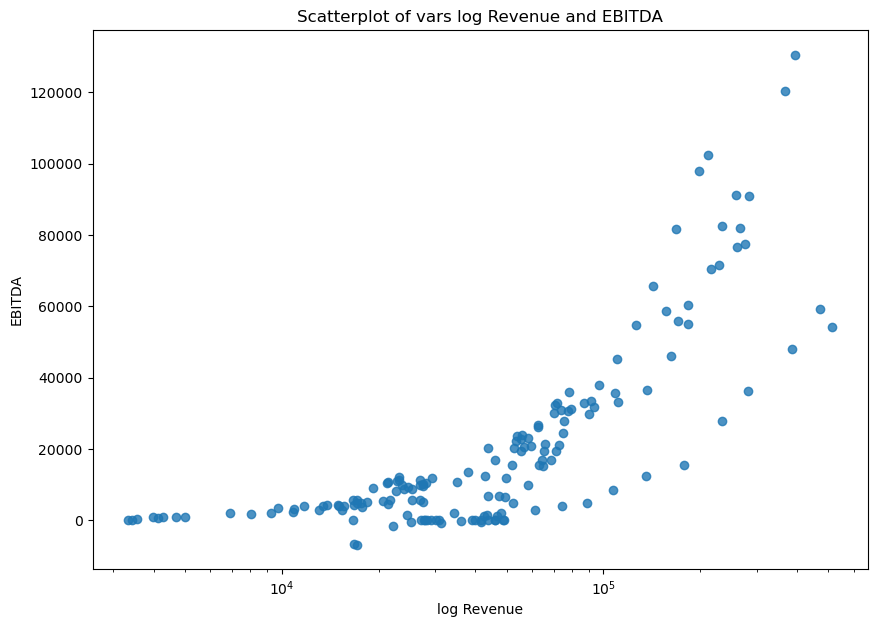

In [43]:
fig, ax = plt.subplots(figsize=(10, 7))

ax.plot(df_merged_copy['Revenue'].values, df_merged_copy['EBITDA'].values, 'o', alpha=.8)

ax.set_title('Scatterplot of vars log Revenue and EBITDA')
ax.set_xlabel('log Revenue')
ax.set_ylabel('EBITDA')

ax.set_xscale('log');

Проанализируем парную линейную регрессию

In [44]:
from statsmodels.formula.api import ols

model1 = ols(formula='EBITDA ~ Revenue', data=df_merged_copy).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                 EBITDA   R-squared:                       0.688
Model:                            OLS   Adj. R-squared:                  0.686
Method:                 Least Squares   F-statistic:                     350.1
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           5.04e-42
Time:                        19:12:03   Log-Likelihood:                -1773.1
No. Observations:                 161   AIC:                             3550.
Df Residuals:                     159   BIC:                             3556.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1920.6204   1518.666      1.265      0.2

In [45]:
model1.params

Intercept    1920.620378
Revenue         0.240611
dtype: float64

линейное уравнение: EBITDA = 1920.620378 +  0.240611 * Revenue

In [46]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame(
    {
        'variable': numerics,
        'vif': [variance_inflation_factor(df_merged_copy[numerics].values, i) for i in range(len(df_merged_copy[numerics].columns))],
    }
)
vif

,variable,vif
0,Revenue,31.988083
1,Gross Profit,35.071371
2,Net Income,25.633775
3,EBITDA,41.444285
4,Share Holder Equity,5.464920
5,ROE,1.456290
6,ROA,7.329021
7,ROI,1.059368
8,Net Profit Margin,7.884372
9,Number of Employees,6.695548


In [47]:
residuals = model1.resid.values
residuals[:10]

array([33740.58297481, 30292.65348006,  9371.95193576, 11955.55945973,
       15975.20527331, 14424.07496015, 16723.18640903, 24331.8954528 ,
       14545.82594024, 12712.4919623 ])

In [48]:
model1.rsquared

np.float64(0.6876700662809541)

In [49]:
model1.rsquared, model1.rsquared_adj

(np.float64(0.6876700662809541), np.float64(0.6857057270751739))

In [50]:
model2 = ols(formula='EBITDA ~ Revenue + ROE + ROI + ROA', data=df_merged_copy).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                 EBITDA   R-squared:                       0.810
Model:                            OLS   Adj. R-squared:                  0.805
Method:                 Least Squares   F-statistic:                     166.6
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           3.18e-55
Time:                        19:12:04   Log-Likelihood:                -1733.0
No. Observations:                 161   AIC:                             3476.
Df Residuals:                     156   BIC:                             3491.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -3738.8600   1347.791     -2.774      0.0

**Вывод:** На показатель EBITDA влияют такие переменные как Revenue, Gross Profit, Net Income (что естесственно, поскольку это составные части формулы расчета EBITDA - как прямые, так и косвенные части), а также Share Holder Equity и ROA. VIF показывает, что значения свыше 25 явным образом подтверждают отсутствие необходимости искать зависимость с Revenue, Gross Profit, Net Income. Остальные показатели коррелируют с EBITDA, model2 объясняет 81% вариации EBITDA, что хорошо, но из модели можно убрать ROI, так как p-value менее 0,05. Можно сказать, что:  
при росте Revenue на 1 → EBITDA растёт на 0.20 (при прочих равных)  
при росте ROE на 1% → EBITDA растёт на 57.26 ед.  
при росте ROA на 1% → EBITDA растёт на ~1005 ед. (очень сильный эффект)  